In [1]:
!pip install -q kaggle

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle authentication configured.")

Kaggle authentication configured.


In [3]:
!kaggle datasets download -d oddrationale/mnist-in-csv

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:00<00:00, 16.8MB/s]



In [4]:
!unzip -o mnist-in-csv.zip -d mnist_data

Archive:  mnist-in-csv.zip
  inflating: mnist_data/mnist_test.csv  
  inflating: mnist_data/mnist_train.csv  


In [5]:
import os

print(os.listdir("mnist_data"))

['mnist_train.csv', 'mnist_test.csv']


In [6]:
import pandas as pd

train_df = pd.read_csv("mnist_data/mnist_train.csv")
test_df = pd.read_csv("mnist_data/mnist_test.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nFirst 5 rows:")
display(train_df.head())

Training shape: (60000, 785)
Testing shape: (10000, 785)

First 5 rows:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print("Training columns:", train_df.columns[:10].tolist(), "...")
print("Total columns:", len(train_df.columns))

print("\nTarget column:", train_df.columns[0])

print("\nDigit distribution:")
print(train_df.iloc[:, 0].value_counts().sort_index())

Training columns: ['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9'] ...
Total columns: 785

Target column: label

Digit distribution:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


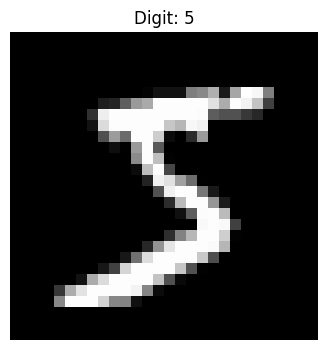

In [8]:
import matplotlib.pyplot as plt

image = train_df.iloc[0, 1:].values.reshape(28, 28)
label = train_df.iloc[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Digit: {label}")
plt.axis("off")
plt.show()

In [9]:
import numpy as np

# Separate features and labels
X_train = train_df.drop("label", axis=1).values
y_train = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Normalize pixel values from 0-255 to 0-1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for CNN: (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nPixel value range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train shape: (60000,)
y_test shape: (10000,)

Pixel value range:
Minimum: 0.0
Maximum: 1.0


In [10]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Build CNN model
cnn_model = Sequential([
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(10, activation="softmax")
])

# Compile the model
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
cnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 101ms/step - accuracy: 0.8978 - loss: 0.3288 - val_accuracy: 0.9808 - val_loss: 0.0654
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.9669 - loss: 0.1116 - val_accuracy: 0.9857 - val_loss: 0.0469
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9754 - loss: 0.0809 - val_accuracy: 0.9877 - val_loss: 0.0386
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9807 - loss: 0.0669 - val_accuracy: 0.9883 - val_loss: 0.0378
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9828 - loss: 0.0569 - val_accuracy: 0.9887 - val_loss: 0.0380
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9850 - loss: 0.0490 - val_accuracy: 0.9912 - val_loss: 0.0317
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.9869 - loss: 0.0420 - val_accuracy: 0.9910 - val_loss: 0.0348
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.9881 - loss: 0.

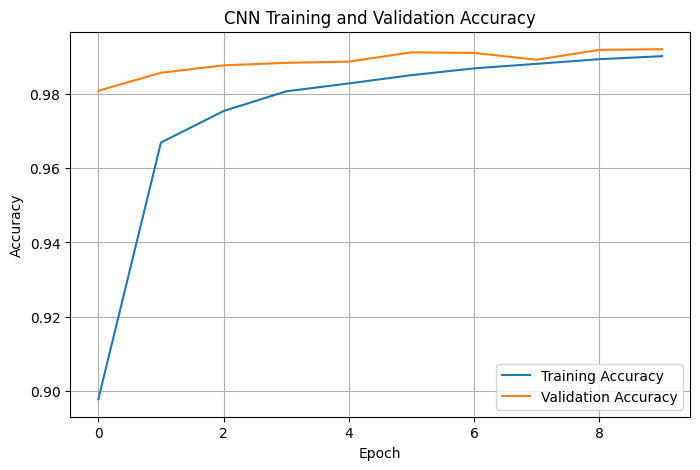

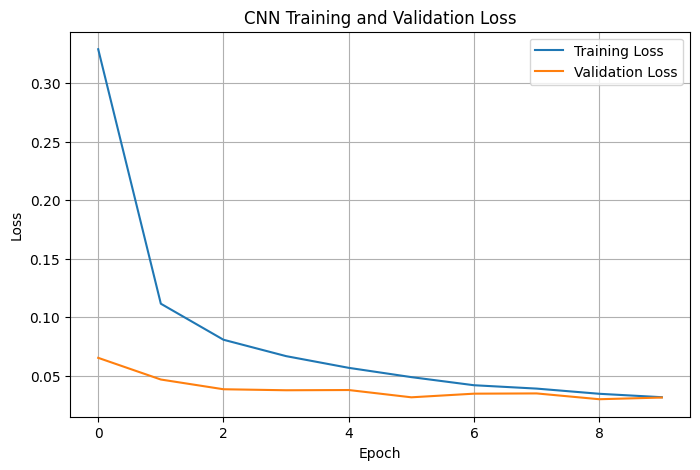

In [13]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9919 - loss: 0.0249
Test Loss: 0.0249
Test Accuracy: 99.1900%


<Figure size 800x800 with 0 Axes>

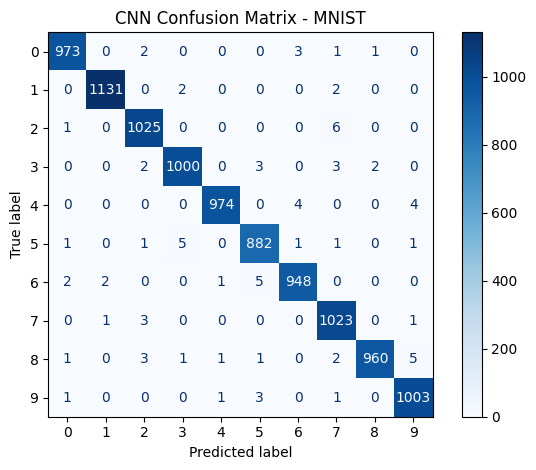

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred_prob = cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("CNN Confusion Matrix - MNIST")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9939    0.9929    0.9934       980
           1     0.9974    0.9965    0.9969      1135
           2     0.9894    0.9932    0.9913      1032
           3     0.9921    0.9901    0.9911      1010
           4     0.9969    0.9919    0.9944       982
           5     0.9866    0.9888    0.9877       892
           6     0.9916    0.9896    0.9906       958
           7     0.9846    0.9951    0.9898      1028
           8     0.9969    0.9856    0.9912       974
           9     0.9892    0.9941    0.9916      1009

    accuracy                         0.9919     10000
   macro avg     0.9918    0.9918    0.9918     10000
weighted avg     0.9919    0.9919    0.9919     10000



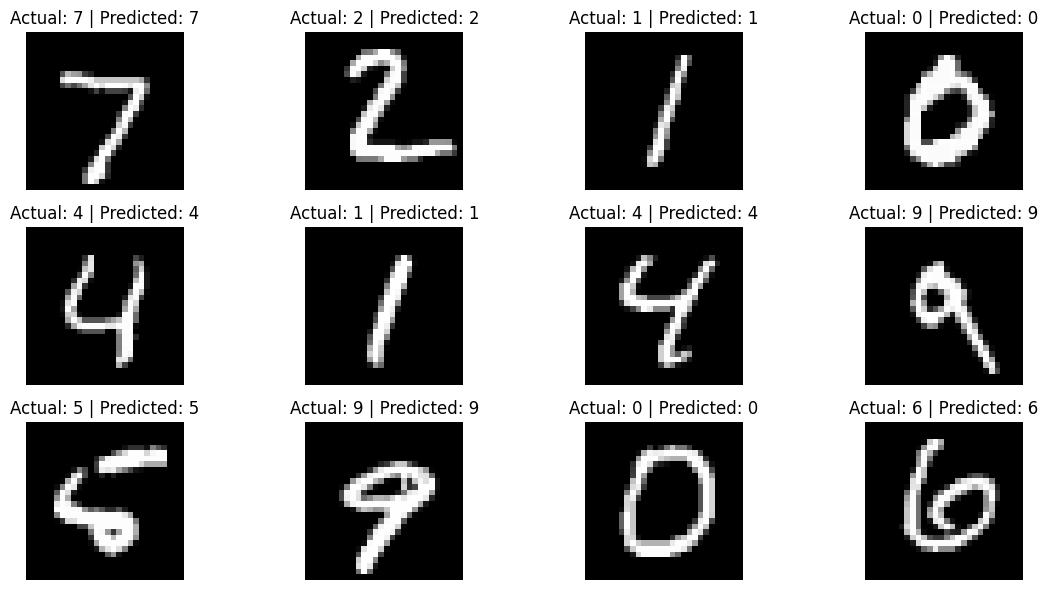

In [17]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]} | Predicted: {y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
cnn_model.save("handwritten_character_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [19]:
import os

print(
    "Model file exists:",
    os.path.exists("handwritten_character_cnn.keras")
)

print(
    "Model size:",
    os.path.getsize("handwritten_character_cnn.keras"),
    "bytes"
)

Model file exists: True
Model size: 2740045 bytes


In [20]:
print("Project files:")

for file in [
    "training_accuracy.png",
    "training_loss.png",
    "confusion_matrix.png",
    "sample_predictions.png",
    "handwritten_character_cnn.keras"
]:
    print(file, "->", os.path.exists(file))

Project files:
training_accuracy.png -> True
training_loss.png -> True
confusion_matrix.png -> True
sample_predictions.png -> True
handwritten_character_cnn.keras -> True


In [21]:
from google.colab import files

for file in [
    "handwritten_character_cnn.keras",
    "training_accuracy.png",
    "training_loss.png",
    "confusion_matrix.png",
    "sample_predictions.png"
]:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>